## 1. Load Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
try:
    df = pd.read_csv('my_data.csv')
    print("CSV successfully loaded into Pandas DataFrame.\n")
except FileNotFoundError:
    print("Error: 'my_data.csv' not found. Run your data collection script first!")
    exit()

CSV successfully loaded into Pandas DataFrame.



In [3]:
# Print first few rows to confirm
df.columns = df.columns.str.strip()
print("First 3 rows of data:")
print(df.head(3), "\n")

First 3 rows of data:
  timestamp  PIR_Motion  Accel_X  Accel_Y  Accel_Z
0   54:24.4           0    0.024    0.007    1.018
1   54:24.4           0    0.024    0.007    1.017
2   54:24.4           0    0.024    0.007    1.017 



In [4]:
# Convert timestamp to datetime objects
df['timestamp'] = pd.to_timedelta('00:' + df['timestamp'].astype(str))
df['elapsed_seconds'] = df['timestamp'].dt.total_seconds()

In [5]:
print("First 3 rows of data:")
print(df.head(3), "\n")

First 3 rows of data:
               timestamp  PIR_Motion  Accel_X  Accel_Y  Accel_Z  \
0 0 days 00:54:24.400000           0    0.024    0.007    1.018   
1 0 days 00:54:24.400000           0    0.024    0.007    1.017   
2 0 days 00:54:24.400000           0    0.024    0.007    1.017   

   elapsed_seconds  
0           3264.4  
1           3264.4  
2           3264.4   



In [6]:
# Check for data quality issues
print("--- Data Quality Checks ---")
print(f"Total rows collected: {len(df)}")
print(f"Missing values per column:\n{df.isnull().sum()}\n")
print(f"Duplicate rows found: {df.duplicated().sum()}\n")
print("Data types after conversion:")
print(df.dtypes, "\n")

--- Data Quality Checks ---
Total rows collected: 16279
Missing values per column:
timestamp          0
PIR_Motion         0
Accel_X            0
Accel_Y            0
Accel_Z            0
elapsed_seconds    0
dtype: int64

Duplicate rows found: 5

Data types after conversion:
timestamp          timedelta64[ns]
PIR_Motion                   int64
Accel_X                    float64
Accel_Y                    float64
Accel_Z                    float64
elapsed_seconds            float64
dtype: object 



In [7]:
# Report statistical summary (Mean, Min, Max, Std Dev)
print("--- Basic Sensor Statistics ---")
stats = df[['PIR_Motion', 'Accel_X', 'Accel_Y', 'Accel_Z']].describe()
# Reordering/filtering to display specifically requested stats
requested_stats = stats.loc[['mean', 'min', 'max', 'std']]
print(requested_stats.to_string())
print("\n")

--- Basic Sensor Statistics ---
      PIR_Motion    Accel_X   Accel_Y      Accel_Z
mean    0.076663   0.026686  0.007212     1.078577
min     0.000000  -0.307000 -0.350000     0.826000
max     1.000000  23.000000  8.000000  1016.000000
std     0.266064   0.302980  0.062957     7.955093




## 2. Create Visualization

In [16]:
# 1. Identify and mask physics-defying hardware spikes (> 5g or < -5g)
for col in ['Accel_X', 'Accel_Y', 'Accel_Z']:
    # Replace outliers with NaN
    df[f'{col}_Clean'] = df[col].mask((df[col] > 3.0) | (df[col] < -3.0))
    
    # Forward-fill and backward-fill the removed outlier points
    df[f'{col}_Clean'] = df[f'{col}_Clean'].ffill().bfill()

# 2. Apply smoothing to the cleaned data
df['PIR_Smooth'] = df['PIR_Motion'].rolling(window=30, center=True).mean()
df['Accel_X_Clean'] = df['Accel_X_Clean'].rolling(window=3, center=True).mean()
df['Accel_Y_Clean'] = df['Accel_Y_Clean'].rolling(window=3, center=True).mean()
df['Accel_Z_Clean'] = df['Accel_Z_Clean'].rolling(window=3, center=True).mean()

Plot generated successfully and saved locally as 'accelerometer_plot.png'!


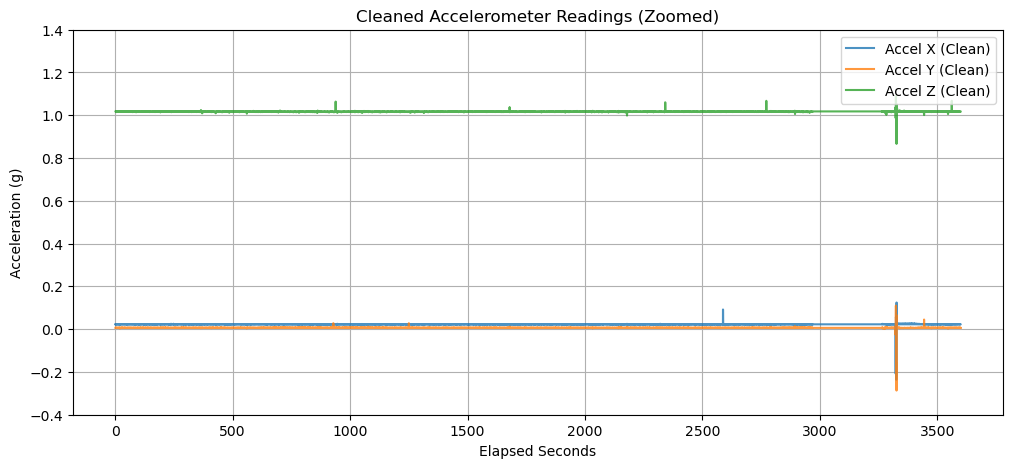

In [19]:
plt.figure(figsize=(12, 5))

# Plot cleaned signals instead of raw unmasked data
plt.plot(df['elapsed_seconds'], df['Accel_X_Clean'], label='Accel X (Clean)',alpha=0.8)
plt.plot(df['elapsed_seconds'], df['Accel_Y_Clean'], label='Accel Y (Clean)',alpha=0.8)
plt.plot(df['elapsed_seconds'], df['Accel_Z_Clean'], label='Accel Z (Clean)',alpha=0.8)

# Set realistic y-limits for accelerometer values (gravity ~1.0g)
plt.ylim(-0.4, 1.4)

plt.xlabel('Elapsed Seconds')
plt.ylabel('Acceleration (g)')
plt.title('Cleaned Accelerometer Readings (Zoomed)')
plt.legend(loc='upper right')
plt.grid(True)

plt.savefig('accelerometer_plot.png', dpi=300)
print("Plot generated successfully and saved locally as 'accelerometer_plot.png'!")

plt.show()

Plot generated successfully and saved locally as 'pir_motion_plot.png'!


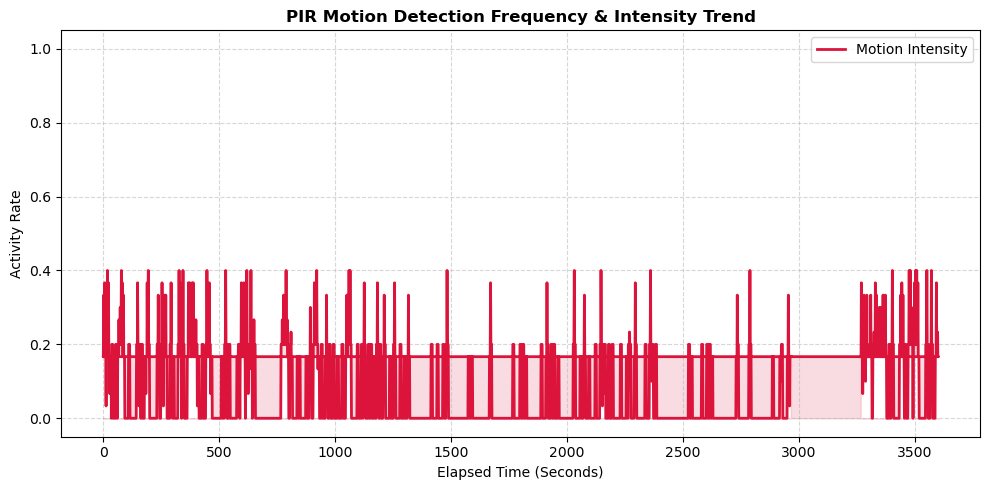

In [20]:

fig, ax = plt.subplots(figsize=(10, 5))

# ------------------------------------------
# Time vs. PIR Motion
# ------------------------------------------
# Smooth data
ax.plot(df['elapsed_seconds'], df['PIR_Smooth'], label='Motion Intensity', color='crimson', linewidth=2)
ax.fill_between(df['elapsed_seconds'], df['PIR_Smooth'], color='crimson', alpha=0.15) 

# Chart Styling
ax.set_title('PIR Motion Detection Frequency & Intensity Trend', fontsize=12, fontweight='bold')
ax.set_xlabel('Elapsed Time (Seconds)', fontsize=10) 
ax.set_ylabel('Activity Rate', fontsize=10)
ax.set_ylim(-0.05, 1.05) 
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(loc='upper right')

plt.tight_layout()

# Save and show
plt.savefig('pir_motion_plot.png', dpi=300)
print("Plot generated successfully and saved locally as 'pir_motion_plot.png'!")
plt.show()